In [433]:
import pandas as pd
from matplotlib import pyplot as plt

fp = "__exps__/y-task-formulations/1. P(y | y_sparse)/2024-12-23_14-05-06_UNETR_y_bar_y_sparse/results.csv"
df = pd.read_csv(fp)
df.head()

,global_train_step,global_val_step,epoch,train_loss,val_loss,z
0,0.0,NaN,0,0.783661,NaN,NaN
1,1.0,NaN,0,0.877567,NaN,NaN
2,2.0,NaN,0,0.704394,NaN,NaN
3,3.0,NaN,0,0.913449,NaN,NaN
4,4.0,NaN,0,0.845116,NaN,NaN


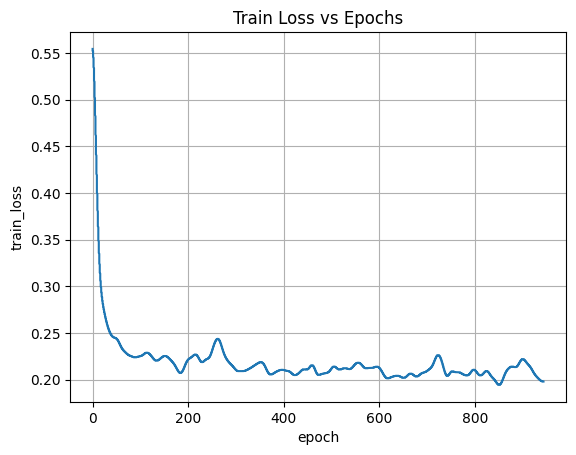

In [434]:
from matplotlib import pyplot as plt
from scipy.ndimage import gaussian_filter1d

SIGMA = 100

_df = df[df["global_train_step"].notna()]
train_steps = _df["epoch"]
train_losses = _df["train_loss"]
train_losses_smoothed = gaussian_filter1d(train_losses, sigma=SIGMA)

# plt.plot(train_steps, train_losses)
plt.plot(train_steps, train_losses_smoothed)
plt.xlabel("epoch")
plt.ylabel("train_loss")
plt.title("Train Loss vs Epochs")
plt.grid()
plt.show()

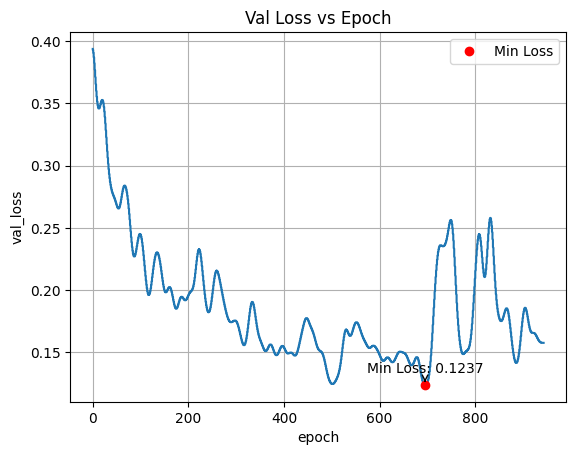

In [435]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d

# Filter the dataframe to get rows with valid global_val_step
_df = df[df["global_val_step"].notna()]

val_steps = _df["epoch"].values
val_losses = _df["val_loss"].values
val_losses_smoothed = gaussian_filter1d(val_losses, sigma=SIGMA)

# Identify the lowest point in the smoothed losses
min_index = np.argmin(val_losses_smoothed)
lowest_val_epoch = val_steps[min_index]
lowest_val_loss = val_losses_smoothed[min_index]

# Plot the smoothed loss
plt.plot(val_steps, val_losses_smoothed)
plt.xlabel("epoch")
plt.ylabel("val_loss")
plt.title("Val Loss vs Epoch")
plt.grid(True)

# Plot a red dot at the lowest loss point
plt.plot(lowest_val_epoch, lowest_val_loss, 'ro', label='Min Loss')
 
# Annotate the lowest loss value on the figure
plt.annotate(f'Min Loss: {lowest_val_loss:.4f}',
             xy=(lowest_val_epoch, lowest_val_loss), 
             xytext=(lowest_val_epoch, lowest_val_loss + 0.010), 
             arrowprops=dict(facecolor='black', arrowstyle='->'),
             ha='center')

plt.legend()
plt.show()

In [436]:
import numpy as np

f"{(np.mean(train_losses[-500: ]) * 100):.5f}%", f"{(np.mean(val_losses[-500: ])):.5f}%"

('20.61573%', '0.16036%')

In [437]:
# _df = df[~df['global_val_step'].notnull()]
# zs = _df["z"]

# # plot a histogram of z
# plt.hist(zs)
# plt.xlabel("z")
# plt.ylabel("count")
# plt.title("Train z distribution")
# plt.grid()
# plt.show()

# # show on figure mean and std of zs
# print(f"mean: {zs.mean()}")
# print(f"std: {zs.std()}")

In [438]:
# _df = df[df['global_val_step'].notnull()]
# zs = _df["z"]

# # plot a histogram of z
# plt.hist(zs)
# plt.xlabel("z")
# plt.ylabel("count")
# plt.title("Val z distribution")
# plt.grid()
# plt.show()

# # show on figure mean and std of zs
# print(f"mean: {zs.mean()}")
# print(f"std: {zs.std()}")

In [439]:
# import math

# # Given mean and standard deviation
# mean = zs.mean()
# std_dev = zs.std()

# # Calculate MAE using the formula for a normal distribution
# mae = std_dev * math.sqrt(2 / math.pi)

# print(f"MAE of always predicting the mean: {mae * 100:.5f}%")